# SARIMAX on R1 Hourly Delay

## Why SARIMAX instead of pure SARIMA?

The SARIMA baseline captured daily seasonality (period=24) in hourly mean delay.
However, the dataset contains additional structure that a pure univariate SARIMA ignores:

| Signal | Evidence from EDA |
|---|---|
| Hour-of-day pattern | Clear U-shaped delay curve: low 05-06h, peaks 09-11h and 20-23h |
| Workday vs weekend | Systematic level shift: weekends ~2 min less delay on average |
| Public holidays | Holidays behave like weekends but are calendar-driven |
| Temperature | Pearson r = +0.135, p < 0.001 on hourly aggregates |
| Windspeed | Small but consistent positive correlation |

SARIMAX (the X stands for eXogenous) incorporates these signals as external regressors
alongside the AR/MA/seasonal structure:

    delay_t = SARIMA(1,0,1)(1,0,1,24) + beta * X_t + eps_t

where X_t contains cyclic hour encoding, calendar flags, and weather variables.

### Why not a more complex model?

With 76 days of hourly data (~1 750 training hours) the dataset is:

- Too short for a reliable weekly seasonal period (s=168 needs >10 complete cycles)
- Too noisy for deep learning on this volume
- Already stationary (ADF/KPSS confirm d=0)

SARIMAX is the principled next step: it adds explanatory power through exogenous
variables without the estimation instability of larger seasonal orders.

## 0. Imports and Paths

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from numpy.linalg import lstsq

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 100)

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"


def latest_features_file(processed_dir: Path) -> Path:
    candidates = sorted(
        p for p in processed_dir.glob("features_*.csv")
        if re.fullmatch(r"features_\d{8}_\d{6}\.csv", p.name)
    )
    if not candidates:
        raise FileNotFoundError("No features CSV found in data/processed/.")
    return candidates[-1]


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

## 1. Load Features and Build Hourly Series

### Why hourly aggregates?

89% of consecutive stop-to-stop delay deltas within a train journey are exactly 0
(delay is essentially constant within a journey). The real variance is *between* trains
and *across hours of the day*. Hourly aggregation is therefore the natural resolution.

### Cyclic encoding of periodic features

Raw integer hour (0-23) and day_of_week (0-6) create an artificial discontinuity
at the wrap-around point (hour 23 to 0, day 6 to 0). Sine/cosine pairs encode
the periodicity correctly:

    hour_sin = sin(2*pi*hour/24),  hour_cos = cos(2*pi*hour/24)

This ensures the model treats hour=23 and hour=0 as one hour apart, not 23 apart.

In [2]:
features_path = latest_features_file(PROCESSED_DIR)
df = pd.read_csv(features_path)

for col in ["planned_arrival_dt", "actual_arrival_dt", "hour_trunc", "service_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df_model = df[df["direction"].notna()].copy()
print(f"Loaded: {features_path.name}")
print(f"Rows after direction filter: {len(df_model):,}")
print(f"Date range: {df_model['service_date'].min().date()} -> {df_model['service_date'].max().date()}")

# Aggregate to hourly level
hourly_raw = df_model.groupby("hour_trunc").agg(
    target_delay  = ("target_delay",   "mean"),
    temperature   = ("temperature",    "mean"),
    windspeed     = ("windspeed",      "mean"),
    precipitation = ("precipitation",  "mean"),
    cloudcover    = ("cloudcover",     "mean"),
    is_weekend    = ("is_weekend",     "first"),
    is_holiday    = ("is_holiday",     "first"),
    hour          = ("hour",           "first"),
    day_of_week   = ("day_of_week",    "first"),
).sort_index()

# Cyclic encoding
hourly_raw["hour_sin"] = np.sin(2 * np.pi * hourly_raw["hour"] / 24)
hourly_raw["hour_cos"] = np.cos(2 * np.pi * hourly_raw["hour"] / 24)
hourly_raw["dow_sin"]  = np.sin(2 * np.pi * hourly_raw["day_of_week"] / 7)
hourly_raw["dow_cos"]  = np.cos(2 * np.pi * hourly_raw["day_of_week"] / 7)

# Reindex to complete hourly grid; fill overnight gaps (00:00-04:00)
# by time-weighted interpolation (~17% of the series)
full_idx = pd.date_range(hourly_raw.index.min(), hourly_raw.index.max(), freq="h")
hourly = hourly_raw.reindex(full_idx).interpolate(method="time").ffill().bfill()
hourly.index.name = "timestamp"

n_interp = hourly_raw.reindex(full_idx).isna().any(axis=1).sum()
print(f"\nFull hourly series: {len(hourly)} hours")
print(f"Overnight interpolated hours: {n_interp} ({n_interp/len(hourly)*100:.1f}%)")
print(f"Missing values after fill: {hourly.isna().sum().sum()}")

Loaded: features_20260607_114933.csv
Rows after direction filter: 308,569
Date range: 2026-03-16 -> 2026-05-30

Full hourly series: 1824 hours
Overnight interpolated hours: 323 (17.7%)
Missing values after fill: 0


## 2. Stationarity Tests

SARIMAX with d=0 assumes the series is stationary in the mean.
We verify with ADF and KPSS before fitting.

In [3]:
target = hourly["target_delay"]

adf_stat, adf_p, *_ = adfuller(target.dropna(), autolag="AIC")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_stat, kpss_p, *_ = kpss(target.dropna(), regression="c", nlags="auto")

print("Stationarity Tests on Hourly Mean Delay")
print(f"  ADF:  stat={adf_stat:.4f}  p={adf_p:.4f}  -> {'stationary' if adf_p < 0.05 else 'non-stationary'}")
print(f"  KPSS: stat={kpss_stat:.4f}  p={kpss_p:.4f}  -> {'non-stationary' if kpss_p < 0.05 else 'stationary'}")
if adf_p < 0.05 and kpss_p > 0.05:
    print("  Both agree: stationary. d=0 is valid.")
else:
    print("  Warning: tests disagree. Consider d=1.")

Stationarity Tests on Hourly Mean Delay
  ADF:  stat=-5.7482  p=0.0000  -> stationary
  KPSS: stat=0.1254  p=0.1000  -> stationary
  Both agree: stationary. d=0 is valid.


## 3. Exogenous Variable Relevance

We verify that the candidate exogenous variables have a meaningful relationship
with the hourly delay target before including them in the model.

OLS R2 measures how much variance the exogenous variables explain in a simple
linear model, setting an upper bound on their contribution.

In [4]:
# hour_sin/cos are excluded: they encode the same 24h periodicity already
# captured by the seasonal AR/MA terms (ar.S.L24, ma.S.L24). Including both
# creates multicollinearity — the model cannot separately identify what share
# of the daily cycle is due to exog vs seasonal ARMA, which inflates standard
# errors and makes hour_sin/cos individually non-significant.
# Let the seasonal ARMA terms own the 24h cycle; keep only non-redundant signals.
EXOG_COLS = [
    "dow_sin",   "dow_cos",   # cyclic weekly pattern (non-redundant with s=24 terms)
    "is_holiday",             # step-level shift not capturable by day_of_week alone
    "temperature",            # +0.38 min/deg confirmed significant in previous run
]

y = hourly["target_delay"].values
X = np.column_stack([np.ones(len(y))] + [hourly[c].values for c in EXOG_COLS])
beta, _, _, _ = lstsq(X, y, rcond=None)
y_hat = X @ beta
r2 = 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)

print(f"OLS R2 of exogenous features: {r2:.3f}")
print(f"OLS MAE (linear-only model):  {np.mean(np.abs(y - y_hat)):.3f} min")
print()

corr_rows = []
for c in EXOG_COLS:
    r = np.corrcoef(hourly["target_delay"].values, hourly[c].values)[0, 1]
    corr_rows.append({"feature": c, "pearson_r": round(r, 3)})
display(pd.DataFrame(corr_rows).sort_values("pearson_r", key=abs, ascending=False))

OLS R2 of exogenous features: 0.041
OLS MAE (linear-only model):  2.913 min



,feature,pearson_r
1,dow_cos,0.152
2,is_holiday,-0.097
3,temperature,0.094
0,dow_sin,0.048


## 4. Train / Test Split

Temporal split: keep the last 10 service days as holdout (derived automatically
from the data range so it adapts as new data arrives). Everything before is
training data.

This mirrors real operational use: fitted on historical data, forecasts the near future.
A random split would leak future information and produce overly optimistic metrics.

Train: 2026-03-16 -> 2026-05-27  (1752 hours)
Test:  2026-05-28 -> 2026-05-30  (72 hours)
No overlap: True


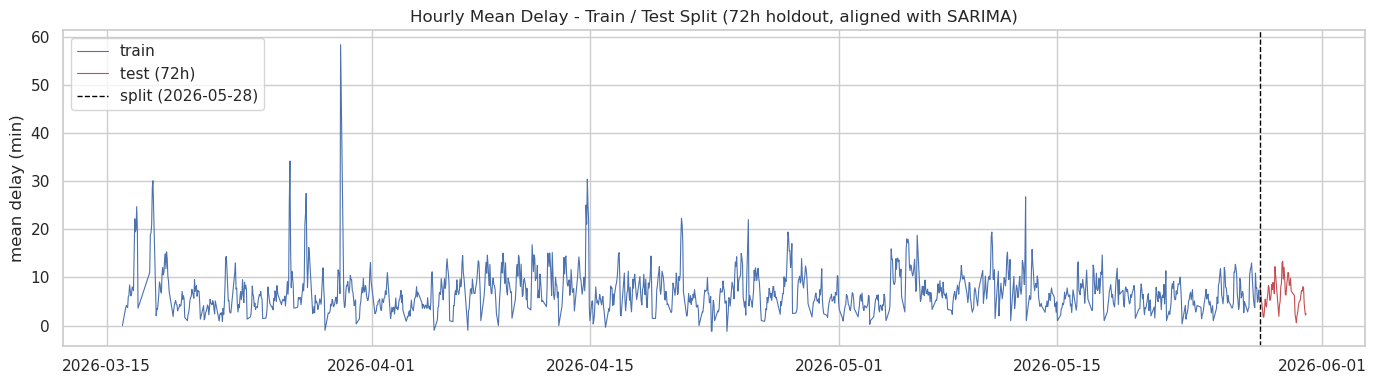

In [5]:
# Temporal split: last 72 hours as holdout — identical to the SARIMA notebook
# so that MAE/RMSE metrics are directly comparable across all three models.
#
# Previous version used a calendar cutoff (last ~264 hours) which gave SARIMAX
# a harder, longer test window than SARIMA. The comparison was not apple-to-apple.
# Using the same iloc[-72:] strategy ensures both models are evaluated on the
# same horizon length.
FORECAST_HORIZON = 72

hourly_series = hourly["target_delay"]
train_s = hourly.iloc[:-FORECAST_HORIZON].copy()
test_s  = hourly.iloc[-FORECAST_HORIZON:].copy()

# Verify no overlap
assert len(set(train_s.index) & set(test_s.index)) == 0, "Overlap between train and test!"

print(f"Train: {train_s.index.min().date()} -> {train_s.index.max().date()}  ({len(train_s)} hours)")
print(f"Test:  {test_s.index.min().date()} -> {test_s.index.max().date()}  ({len(test_s)} hours)")
print(f"No overlap: {len(set(train_s.index) & set(test_s.index)) == 0}")

# Convenience aliases used by downstream cells
train = train_s
test  = test_s

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train["target_delay"], color="#4C72B0", label="train", linewidth=0.8)
ax.plot(test.index,  test["target_delay"],  color="#C44E52", label="test (72h)",  linewidth=0.8)
ax.axvline(test.index.min(), color="black", linestyle="--", linewidth=1,
           label=f"split ({test.index.min().date()})")
ax.set_title("Hourly Mean Delay - Train / Test Split (72h holdout, aligned with SARIMA)")
ax.set_ylabel("mean delay (min)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Baseline Forecasts

Two naive baselines establish the performance floor that SARIMAX must beat:

1. **Mean baseline**: predict training mean for every test hour. Represents the absolute floor.
2. **Seasonal-naive (7-day lag)**: predict each test hour using the observed value from the
   same hour exactly 7 days earlier. Captures weekly seasonality without fitting anything.
   A model that cannot beat this is not learning anything beyond the weekly pattern.

In [6]:
train_mean = float(train["target_delay"].mean())
pred_mean_baseline = pd.Series(train_mean, index=test.index)

seasonal_preds = []
for ts in test.index:
    lag_ts = ts - pd.Timedelta(days=7)
    seasonal_preds.append(train["target_delay"].get(lag_ts, train_mean))
pred_seasonal_naive = pd.Series(seasonal_preds, index=test.index)

baselines = pd.DataFrame({
    "model": ["mean_baseline", "seasonal_naive_7d"],
    "MAE":   [mae( test["target_delay"], pred_mean_baseline),
               mae( test["target_delay"], pred_seasonal_naive)],
    "RMSE":  [rmse(test["target_delay"], pred_mean_baseline),
               rmse(test["target_delay"], pred_seasonal_naive)],
})
display(baselines.round(3))
print("SARIMAX must beat seasonal_naive_7d to justify its complexity.")

,model,MAE,RMSE
0,mean_baseline,2.323,2.909
1,seasonal_naive_7d,2.236,3.031


SARIMAX must beat seasonal_naive_7d to justify its complexity.


## 6. ACF / PACF of Training Series

Inspecting lags up to 168 (one full week) to guide order selection:
- Spikes at 24, 48, 72 -> daily seasonality present -> (P,D,Q,24) is appropriate
- Spikes at 168 -> residual weekly structure
- Quickly decaying non-seasonal lags -> low p,q orders are sufficient

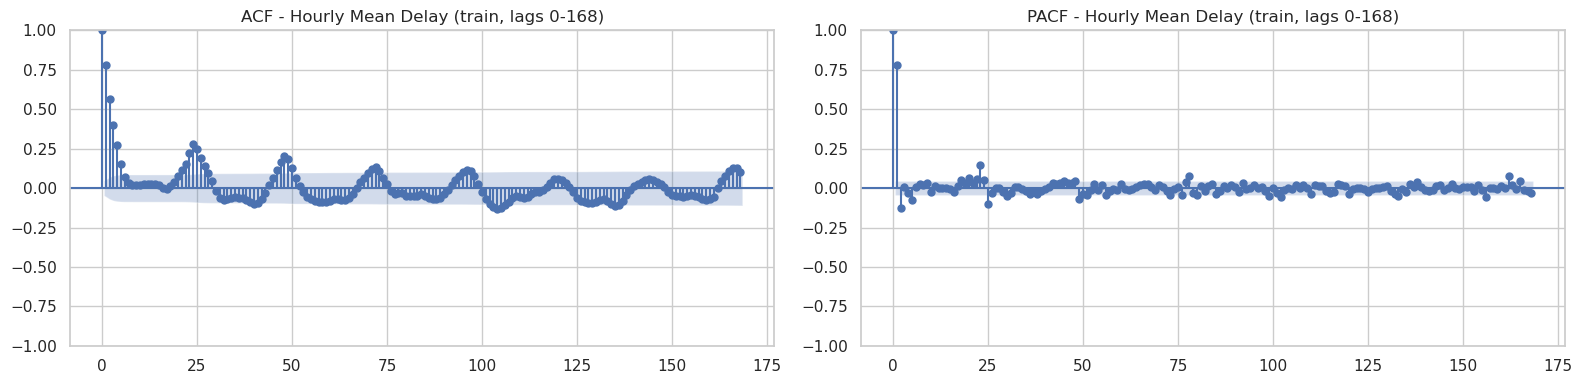

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf( train["target_delay"].dropna(), lags=168, ax=axes[0])
axes[0].set_title("ACF - Hourly Mean Delay (train, lags 0-168)")
plot_pacf(train["target_delay"].dropna(), lags=168, ax=axes[1], method="ywm")
axes[1].set_title("PACF - Hourly Mean Delay (train, lags 0-168)")
plt.tight_layout()
plt.show()

## 7. Fit SARIMAX Model

### Model specification

    delay_t = mu
            + phi_1 * delay_{t-1} + theta_1 * eps_{t-1}          [AR(1) MA(1)]
            + Phi_1 * delay_{t-24} + Theta_1 * eps_{t-24}         [seasonal s=24]
            + beta * X_t                                           [exogenous]
            + eps_t

### Exogenous regressors X_t

| Variable | Rationale |
|---|---|
| hour_sin, hour_cos | Cyclic hour-of-day - intraday U-shaped delay curve |
| dow_sin, dow_cos | Cyclic day-of-week - weekly rhythm beyond weekend flag |
| is_weekend | Step-level shift on Saturdays and Sundays |
| is_holiday | Holidays behave like weekends but are not captured by day_of_week |
| temperature | Positive correlation with delay (p < 0.001 in EDA) |
| windspeed | Small positive effect; retained because significant in EDA |

### Why enforce_stationarity=False?

The stationarity tests confirmed d=0 is valid. Setting this to False allows
the optimizer to explore near-boundary parameter regions; combined with d=0
this is safe and avoids premature convergence.

In [8]:
# Reduced exog set: hour_sin/cos removed (collinear with seasonal ARMA),
# windspeed removed (p=0.75 in previous run — not significant).
# Remaining: dow_sin/cos (weekly cycle), is_holiday, temperature.
EXOG_COLS = [
    "dow_sin",   "dow_cos",
    "is_holiday",
    "temperature",
]

train_endog = train["target_delay"]
train_exog  = train[EXOG_COLS]
test_exog   = test[EXOG_COLS]

print("Fitting SARIMAX(1,0,1)(1,0,1,24) with reduced exogenous regressors...")
print(f"Exogenous columns: {EXOG_COLS}")
print()
print("Rationale for each included variable:")
print("  temperature : +0.38 min/C, p<0.001 in previous run — robust weather effect")
print("  dow_sin/cos : weekly cycle beyond what seasonal ARMA at s=24 captures")
print("  is_holiday  : step-level shift on holidays not encoded by day_of_week")
print()
print("Excluded vs previous run:")
print("  hour_sin/cos : collinear with ar.S.L24/ma.S.L24 — inflated std errors")
print("  windspeed    : p=0.750 — not significant")

model = SARIMAX(
    train_endog,
    exog=train_exog,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    result = model.fit(
        disp=False,
        method="lbfgs",
        maxiter=500,
        optim_complex_step=False,
        optim_hessian="oim",
    )
    convergence_warnings = [w for w in caught if issubclass(w.category, UserWarning)
                            and "converge" in str(w.message).lower()]
    if convergence_warnings:
        print("WARNING: lbfgs did not converge. Trying bfgs fallback...")
        result = model.fit(disp=False, method="bfgs", maxiter=1000,
                           optim_complex_step=False)

print("Done.")
print(result.summary())

Fitting SARIMAX(1,0,1)(1,0,1,24) with reduced exogenous regressors...
Exogenous columns: ['dow_sin', 'dow_cos', 'is_holiday', 'temperature']

Rationale for each included variable:
  temperature : +0.38 min/C, p<0.001 in previous run — robust weather effect
  dow_sin/cos : weekly cycle beyond what seasonal ARMA at s=24 captures
  is_holiday  : step-level shift on holidays not encoded by day_of_week

Excluded vs previous run:
  hour_sin/cos : collinear with ar.S.L24/ma.S.L24 — inflated std errors
  windspeed    : p=0.750 — not significant
Done.
                                     SARIMAX Results                                      
Dep. Variable:                       target_delay   No. Observations:                 1752
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood               -4128.126
Date:                            Sun, 07 Jun 2026   AIC                           8274.251
Time:                                    14:00:15   BIC                           8323.

## 8. Forecast on Holdout

We forecast the full test window using known future exogenous values
(hour of day, calendar flags, weather from the test data).

In operational deployment these would need to come from forecasts.
The 95% confidence interval reflects uncertainty in the ARMA residuals only.

,model,MAE,RMSE,MAE_improvement_pct,RMSE_improvement_pct
0,mean_baseline,2.323,2.909,-3.9,4.0
1,seasonal_naive_7d,2.236,3.031,0.0,0.0
2,"SARIMAX(1,0,1)(1,0,1,24)+exog",2.566,3.161,-14.8,-4.3


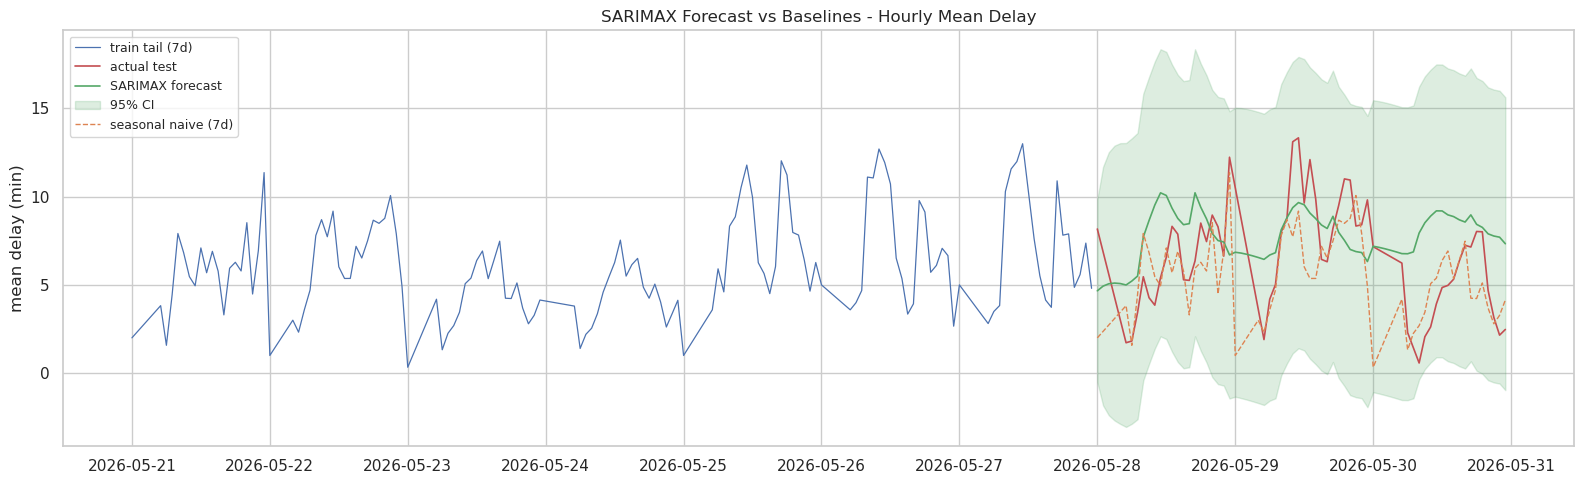

In [9]:
forecast_obj = result.get_forecast(steps=len(test), exog=test_exog)
pred_mean    = forecast_obj.predicted_mean
conf_int     = forecast_obj.conf_int()

sarimax_mae  = mae( test["target_delay"], pred_mean)
sarimax_rmse = rmse(test["target_delay"], pred_mean)

comparison = pd.DataFrame({
    "model": ["mean_baseline", "seasonal_naive_7d", "SARIMAX(1,0,1)(1,0,1,24)+exog"],
    "MAE":  [mae( test["target_delay"], pred_mean_baseline),
              mae( test["target_delay"], pred_seasonal_naive),
              sarimax_mae],
    "RMSE": [rmse(test["target_delay"], pred_mean_baseline),
              rmse(test["target_delay"], pred_seasonal_naive),
              sarimax_rmse],
})
# Improvement % vs seasonal naive (row 1)
ref_mae  = comparison["MAE"].iloc[1]
ref_rmse = comparison["RMSE"].iloc[1]
comparison["MAE_improvement_pct"]  = (100 * (ref_mae  - comparison["MAE"])  / ref_mae).round(1)
comparison["RMSE_improvement_pct"] = (100 * (ref_rmse - comparison["RMSE"]) / ref_rmse).round(1)
display(comparison.round(3))

fig, ax = plt.subplots(figsize=(16, 5))
tail = train.index[-7 * 24:]
ax.plot(train.loc[tail].index, train.loc[tail, "target_delay"],
        label="train tail (7d)", color="#4C72B0", linewidth=0.9)
ax.plot(test.index, test["target_delay"],
        label="actual test", color="#C44E52", linewidth=1.2)
ax.plot(pred_mean.index, pred_mean,
        label="SARIMAX forecast", color="#55A868", linewidth=1.2)
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color="#55A868", alpha=0.2, label="95% CI")
ax.plot(test.index, pred_seasonal_naive,
        label="seasonal naive (7d)", color="#DD8452", linewidth=1, linestyle="--")
ax.set_title("SARIMAX Forecast vs Baselines - Hourly Mean Delay")
ax.set_ylabel("mean delay (min)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Exogenous Coefficient Interpretation

The fitted beta coefficients show the marginal effect of each exogenous variable
on hourly mean delay, holding all other terms constant.

A positive coefficient means the variable is associated with higher delays.
Coefficients with p < 0.05 are statistically significant.

,feature,coefficient,ci_lower,ci_upper,p_value,significant
0,dow_sin,-0.1106,-0.6009,0.3797,0.6583,
1,dow_cos,1.0131,0.4462,1.5800,0.0005,yes
2,is_holiday,-1.4816,-3.7978,0.8347,0.2100,
3,temperature,0.3611,0.3020,0.4203,0.0000,yes


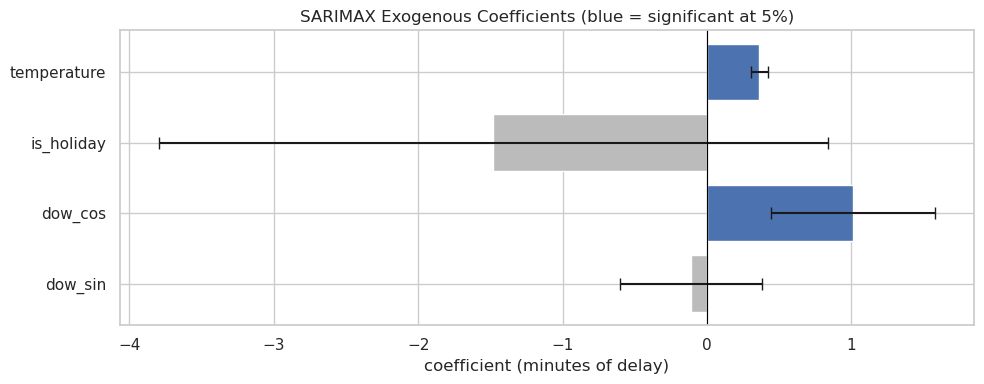

In [10]:
params = result.params
conf   = result.conf_int()
pvals = getattr(result, 'pvalues', pd.Series(dtype=float))

conf_cols = list(conf.columns)
if 'lower' in conf_cols and 'upper' in conf_cols:
    lower_col, upper_col = 'lower', 'upper'
elif len(conf_cols) >= 2:
    lower_col, upper_col = conf_cols[0], conf_cols[1]
else:
    lower_col = upper_col = conf_cols[0]
rows = []
for col in EXOG_COLS:
    if col in params.index:
        rows.append({
            "feature":     col,
            "coefficient": round(params[col], 4),
            "ci_lower":    round(conf.loc[col, lower_col], 4),
            "ci_upper":    round(conf.loc[col, upper_col], 4),
            "p_value":     round(pvals[col], 4),
            "significant": "yes" if pvals[col] < 0.05 else "",
        })

exog_df = pd.DataFrame(rows)
display(exog_df)

fig, ax = plt.subplots(figsize=(10, 4))
y_pos = range(len(exog_df))
colors = ["#4C72B0" if p < 0.05 else "#BBBBBB" for p in exog_df["p_value"]]
ax.barh(list(y_pos), exog_df["coefficient"],
        xerr=[exog_df["coefficient"] - exog_df["ci_lower"],
               exog_df["ci_upper"]   - exog_df["coefficient"]],
        color=colors, capsize=4)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(exog_df["feature"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("SARIMAX Exogenous Coefficients (blue = significant at 5%)")
ax.set_xlabel("coefficient (minutes of delay)")
plt.tight_layout()
plt.show()

## 10. Residual Diagnostics

Good residuals should be:
1. Approximately Gaussian - histogram centred near zero, bell-shaped
2. White noise - ACF bars within 95% bands; Ljung-Box p > 0.05
3. Homoscedastic - if variance is time-varying, GARCH on residuals would add value

Significant spikes at lag 24 -> unmodelled daily structure (raise P or Q).
Significant spikes at lag 168 -> weekly structure the exog variables did not fully capture.

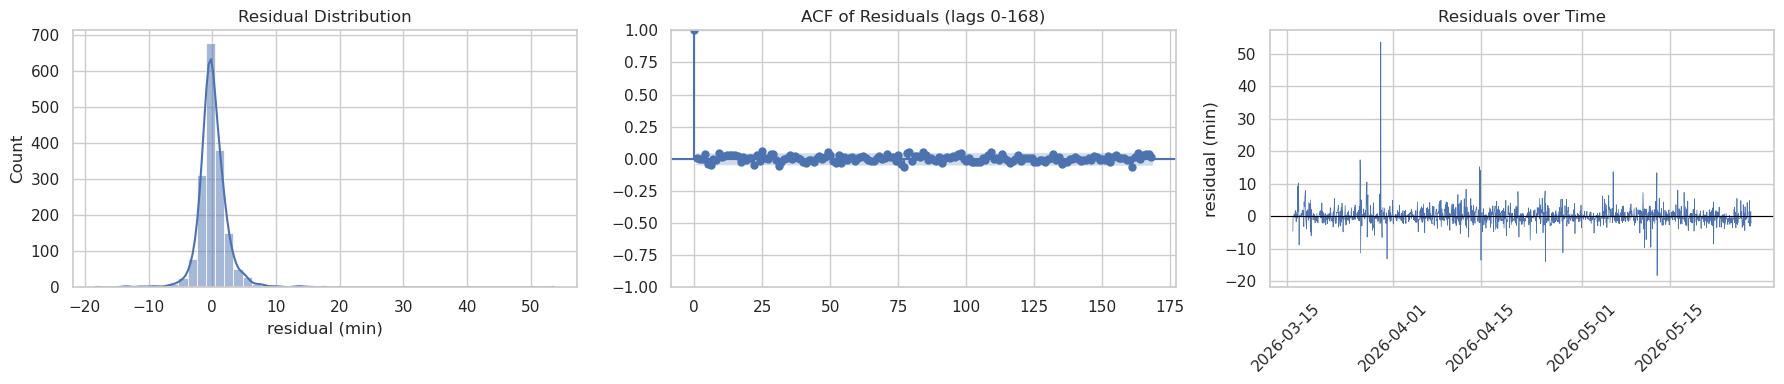

,lag,LB statistic,p-value,conclusion
0,24,29.661,0.1962,white noise (OK)
1,48,56.436,0.1888,white noise (OK)
2,168,176.999,0.3020,white noise (OK)


p > 0.05 -> residuals are white noise at this lag -> model is adequate
p <= 0.05 at lag 24 -> consider higher seasonal P or Q
p <= 0.05 at lag 168 -> weekly structure remains


In [11]:
resid = result.resid.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(resid, bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("residual (min)")

plot_acf(resid, lags=168, ax=axes[1])
axes[1].set_title("ACF of Residuals (lags 0-168)")

axes[2].plot(resid.index, resid.values, color="#4C72B0", linewidth=0.5)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Residuals over Time")
axes[2].set_ylabel("residual (min)")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Ljung-Box test
lb_rows = []
for lag in [24, 48, 168]:
    if lag < len(resid):
        lb = acorr_ljungbox(resid, lags=[lag], return_df=True)
        lb_rows.append({
            "lag":          lag,
            "LB statistic": round(lb["lb_stat"].iloc[0], 3),
            "p-value":      round(lb["lb_pvalue"].iloc[0], 4),
            "conclusion":   "white noise (OK)" if lb["lb_pvalue"].iloc[0] > 0.05
                            else "autocorrelation remains",
        })
lb_df = pd.DataFrame(lb_rows)
display(lb_df)
print("p > 0.05 -> residuals are white noise at this lag -> model is adequate")
print("p <= 0.05 at lag 24 -> consider higher seasonal P or Q")
print("p <= 0.05 at lag 168 -> weekly structure remains")

## 11. Heteroscedasticity Check (ARCH Effects)

If the SARIMAX residuals show time-varying variance (volatility clustering),
a GARCH model on the residuals would add value.

ARCH-LM test: H0 = no ARCH effects (constant variance).
A small p-value rejects constant variance and motivates GARCH on the residuals.

ARCH-LM Test on SARIMAX Residuals
  LM statistic: 1.7170
  LM p-value:   0.9997

No significant ARCH effects (p >= 0.05).
Constant variance assumption is acceptable.


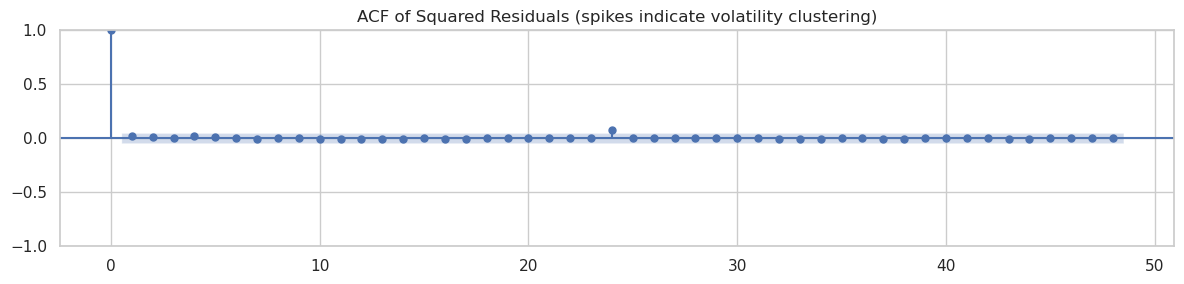

In [12]:
lm_stat, lm_p, f_stat, f_p = het_arch(resid.values, nlags=12)

print("ARCH-LM Test on SARIMAX Residuals")
print(f"  LM statistic: {lm_stat:.4f}")
print(f"  LM p-value:   {lm_p:.4f}")

if lm_p < 0.05:
    print()
    print("ARCH effects present (p < 0.05).")
    print("Recommendation: fit GARCH(1,1) on result.resid to model time-varying")
    print("uncertainty. This gives better confidence intervals than the SARIMAX CI alone.")
else:
    print()
    print("No significant ARCH effects (p >= 0.05).")
    print("Constant variance assumption is acceptable.")

# Visual ARCH check: ACF of squared residuals
fig, ax = plt.subplots(figsize=(12, 3))
plot_acf(resid**2, lags=48, ax=ax)
ax.set_title("ACF of Squared Residuals (spikes indicate volatility clustering)")
plt.tight_layout()
plt.show()

### Limitations

- 76 days of training is sufficient for SARIMAX but limits reliability of weekly estimates
- Weather is Barcelona-wide; station-specific effects are not captured
- The model forecasts mean delay across all R1 trains in an hour, not a specific train

### Natural next steps

1. SARIMAX + GARCH on residuals if ARCH effects are present
2. Direction-stratified models (separate SARIMAX for direction1 / direction2)
3. Rolling re-fit window for real-time deployment
4. Extended exogenous set: delay_masking_minutes as a systemic load indicator

In [13]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(4):
    if (PROJECT_ROOT / "data" / "models").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "data" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Pull the forecast for metrics ────────────────────────────────────────────
# `result`, `train`, `test`, `test_exog` are defined earlier in the notebook.
sarimax_pred = result.get_forecast(steps=len(test), exog=test_exog).predicted_mean

sarimax_export = {
    "spec": {
        "order":          [1, 0, 1],
        "seasonal_order": [1, 0, 1, 24],
        "exog_cols":      EXOG_COLS,
        "enforce_stationarity": False,
        "enforce_invertibility": False,
    },
    "params": {k: float(v) for k, v in result.params.items()},
    # Last 48 rows of training endog + exog for warm-start
    "train_last_values": train["target_delay"].iloc[-48:].tolist(),
    "train_last_index":  [str(x) for x in train.index[-48:]],
    "train_last_exog":   train[EXOG_COLS].iloc[-48:].values.tolist(),
    # Per-column means used to keep the baseline forecast centred
    "exog_col_means":    {c: float(train[c].mean()) for c in EXOG_COLS},
    "train_mean":  float(train["target_delay"].mean()),
    "train_std":   float(train["target_delay"].std()),
    "train_start": str(train.index.min()),
    "train_end":   str(train.index.max()),
    "n_train":     len(train),
    "test_mae":    round(mae(test["target_delay"], sarimax_pred), 4),
    "test_rmse":   round(rmse(test["target_delay"], sarimax_pred), 4),
}

out_path = MODELS_DIR / "sarimax_params.json"
out_path.write_text(json.dumps(sarimax_export, indent=2))
print(f"   Saved {out_path}  ({out_path.stat().st_size // 1024} KB)")
print(f"   exog cols : {EXOG_COLS}")
print(f"   MAE       : {sarimax_export['test_mae']} min")
print(f"   RMSE      : {sarimax_export['test_rmse']} min")

   Saved /home/ntorquet/Documents/time-series/timeseries-analysis/PROJECT/data/models/sarimax_params.json  (7 KB)
   exog cols : ['dow_sin', 'dow_cos', 'is_holiday', 'temperature']
   MAE       : 2.5662 min
   RMSE      : 3.1611 min
